# The Leaky Integrate-and-Fire Neuron

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

The Leaky Integrate-and-Fire (LIF) Neuron model is a fundamental mathematical representation of a biological neuron. It models a neuron's membrane potential as an electrical circuit that adds up incoming input while continuously leaking charge. If the neuron accumulates enough charge to hit some spiking threshold, it emits a spike and resets its membrane potential. The dynamics of the LIF neuron are given by
$$
C \dot\mu = \frac{\mu^0 - \mu(t)}{R} + I(t).
$$
The goal in this notebook is to use first principles to re-construct this equation.

An LIF neuron essentially does two things: it accumulates input over time, and it leaks its charge. To start, let's introduce some of the components of an LIF neuron. 

Let $\mu(t)$ denote the membrane potential at time $t$. This represents charge accumulated across the cell membrane and measures how "close" a neuron is to firing.

Two forces act on $\mu(t)$ at every instant:

1. Leak: accumulated charge will "leak" out of the neuron since the membrane is not perfectly insulated. The rate of leak is determined by how far the current membrane potential is from an equilibrium resting potential. Let $\mu^0$ represent this membrane resting potential.
2. Inputs: incoming signals from other neurons or an external stimulus push the membrane potential toward the spiking threshold. The inputs feeding into the LIF neuron can be described with a time-indexed function, $I(t)$.

Armed with these three pieces, $\mu(t)$, $\mu^0$, and $I(t)$, we can define the fundamental core of an LIF neuron.

## LIF Fundamentals: Leak and Input

Using three pieces, we can define a basic differential equation that captures leak and input dynamics of the LIF neuron:
$$
\dot\mu = \mu^0 - \mu(t) + I(t),
$$
where $\dot\mu$ is the temporal derivative of the membrane potential $\mu(t)$. This equation posits that the change in membrane potential is dependent on a leak component and an input component.

$$\dot\mu = \underbrace{\mu^0 - \mu(t)}_{\text{leak}} + \underbrace{I(t)}_{\text{input}}$$

### Leak Demonstration

For now, let's consider the case where no input is being supplied to the neuron. That is, $I(t) = 0$ for all time steps $t$. In this case, the temporal derivative of $\mu(t)$ depends only on the leak term:
$$
\dot\mu = \mu^0 - \mu(t).
$$

This captures the biophysical leaky behavior of real neurons. The resting potential of a biological neuron is an electrochemical equilibrium between the ions inside of the cell and the ions outside of the cell. The neuron's membrane potential wants to be in equilibrium, so any deviation from the resting potential faces a restoring force that tries to bring the membrane potential back to rest.

The equation above reinforces $\mu^0$'s role as the membranes resting potential. If $\mu(t)$ is less than $\mu^0$, then $\dot\mu$ is positive and the membrane potential is increasing (toward $\mu^0$). If $\mu(t)$ is greater than $\mu^0$, then $\dot\mu$ is negative and the membrane potential is decreasing (still toward $\mu^0$). And if $\mu(t) = \mu^0$, then $\dot\mu = 0$ and the membrane potential is happy where it is; it does not change.

Let's simulate these leaky dynamics. First, we will define some parameters.

In [2]:
# LIF Parameters
t_max = 10 # 10 s of recording time
dt = 0.01 # 10 ms timesteps
mu_0 = -60 # -60 mV resting potential
step_end = int(t_max / dt) # Number of total timesteps

As a brief aside, in order to simulate the membrane voltage in discrete time, we use discrete time integration. This amounts to calculating the temporal derivative at each time step and nudging the membrane potential in that direction by a little amount. For small enough time steps ($dt \to 0$), then
$$
\mu(t + dt) = \mu(t) + \dot\mu \:dt
$$

For our purposes, we use `dt = 0.01`.


Let's start by setting the initial membrane potential above the resting potential, so $\mu(0) > \mu^0$. We'll see how the membrane potential converges to the resting potential.

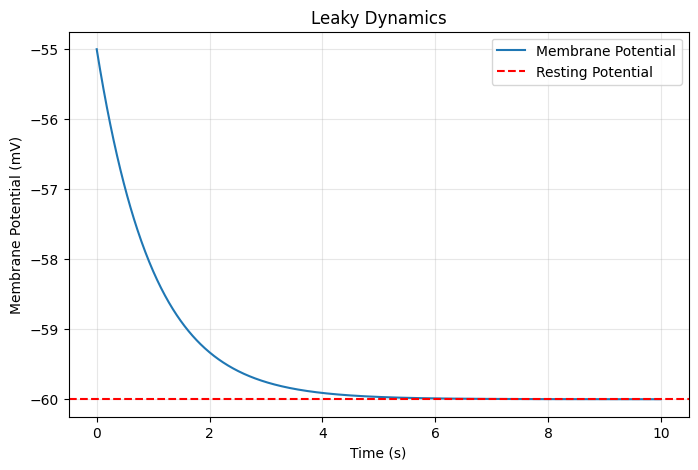

In [3]:
# Intitialize membrane potential
mu = np.zeros(step_end)
mu[0] = -55 # -55 mV initial potential

# Simulate dynamics
for i in range (1, step_end):
    mu[i] = mu[i-1] + (mu_0 - mu[i-1]) * dt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, t_max, dt), mu, label="Membrane Potential")
ax.axhline(y=mu_0, color="r", linestyle="--", label="Resting Potential")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Membrane Potential (mV)")
ax.set_title("Leaky Dynamics")
ax.legend(); ax.grid(alpha=0.3)

plt.show()

So with no external input, any membrane potential above the resting potential eventually falls to the resting potential.

Likewise, any membrane potential below the resting potential will eventually rise to the resting potential.

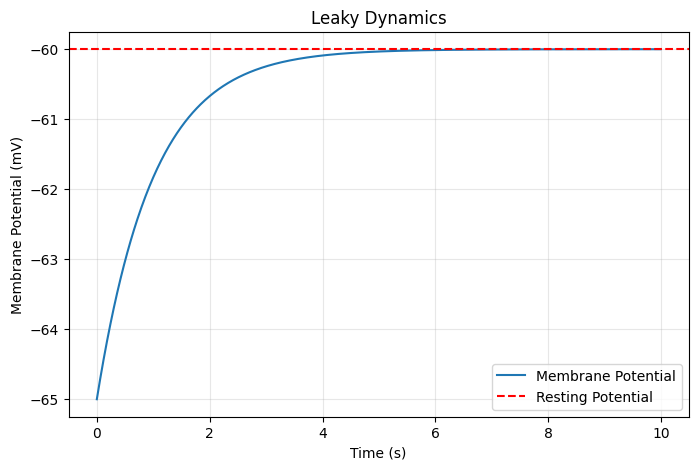

In [4]:
# Intitialize membrane potential
mu = np.zeros(step_end)
mu[0] = -65 # 65 mV initial potential

# Simulate dynamics
for i in range (1, step_end):
    mu[i] = mu[i-1] + (mu_0 - mu[i-1]) * dt

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, t_max, dt), mu, label="Membrane Potential")
ax.axhline(y=mu_0, color="r", linestyle="--", label="Resting Potential")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Membrane Potential (mV)")
ax.set_title("Leaky Dynamics")
ax.legend(); ax.grid(alpha=0.3)

plt.show()

So the leak term in the differential equation of the LIF neuron acts to restore the neuron's membrane potential to its resting potential. This term is always active, representing the electrochemical forces that act on the neuron.

### Input Demonstration

Now let's see how the membrane dynamics respond to external inputs.

Reintroducing the input $I(t)$, the dynamics of the LIF neuron's membrane potential is given by
$$\dot\mu = \mu^0 - \mu(t) + \underbrace{I(t)}_{\text{input}}$$
For the purposes of this demonstration, let's assume $I(t)$ for the simulation period (10 seconds), we have a constant input of 4 from $t = 2$ to $t = 8$.

$I(t)$ is plotted below:

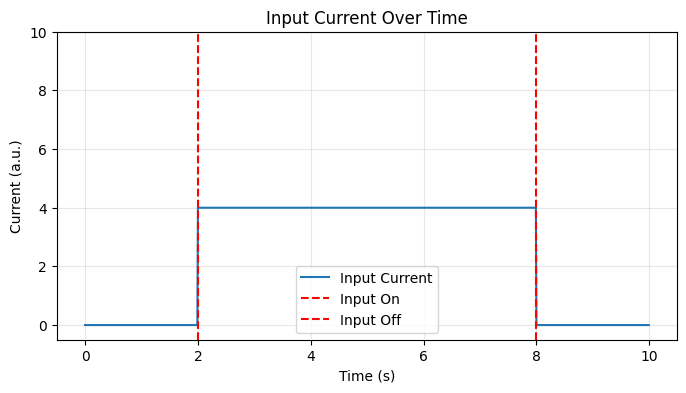

In [5]:
# Define Input Current

I = np.zeros(step_end)
I[200:800] = 4.0 # input = 4 from 2 s to 8 s

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(0, t_max, dt), I, label="Input Current")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Current (a.u.)")
ax.set_title("Input Current Over Time")
ax.axvline(x=2, color="r", ls="--", label="Input On")
ax.axvline(x=8, color="r", ls="--", label="Input Off")
ax.set_ylim(-0.5,10); ax.legend(); ax.grid(alpha=0.3)
plt.show()

When we look at the equation 
$$
\dot\mu = \mu^0 - \mu(t) + I(t),
$$
it's clear that this positive input is going to increase the membrane potential. Let's now plot the membrane potential over time with this input.

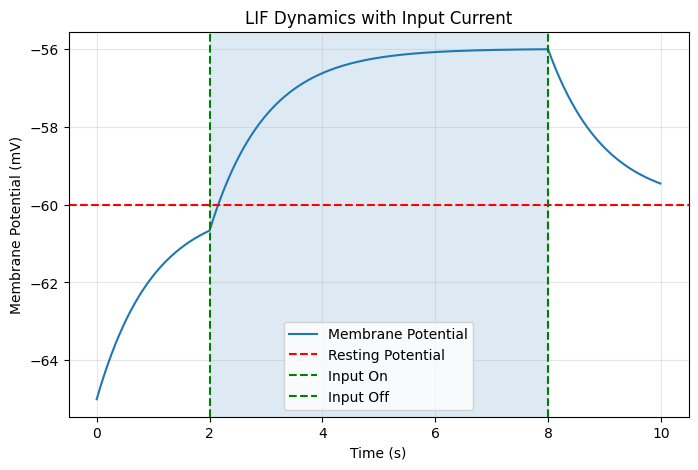

In [6]:
# Same input as above
I = np.zeros(step_end)
I[200:800] = 4.0 # input = 4 from 2 s to 8 s

# Store membrane potential
mu = np.zeros(step_end)
mu[0] = -65 # 65 mV initial potential

# Simulate dynamics
for i in range (1, step_end):
    mu[i] = mu[i-1] + (mu_0 - mu[i-1] + I[i-1]) * dt

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, t_max, dt), mu, label="Membrane Potential")
ax.axhline(y=mu_0, color="r", linestyle="--", label="Resting Potential")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Membrane Potential (mV)")
ax.set_title("LIF Dynamics with Input Current")

# Show input current
ax.axvline(x=2, color="g", ls="--", label="Input On")
ax.axvline(x=8, color="g", ls="--", label="Input Off")
ax.axvspan(2, 8, alpha=0.15)

ax.legend(); ax.grid(alpha=0.3)

plt.show()

In this plot, there is no input between time $t=0$ and $t=2$, so the membrane potential behaves like in the demonstration above: it starts heading toward equilibrium resting potential.

Then, when an input current is introduced starting at $t=2$, it *drives* the membrane potential above the resting potential. It reaches about -56 mV before the input current shuts off, and once again the membrane potential leaks back towards resting potential.

Let's try another input function: a sinusoidal input:
$$
I(t) = 40 \left( 1 + \sin\left( \frac t {20} \right)\right)
$$

Note we add 1 to keep the input positive.

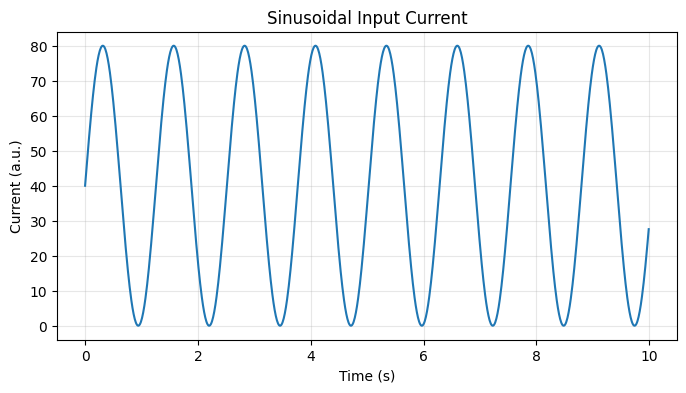

In [7]:
I = np.zeros(step_end)
for i in range(step_end):
    I[i] = 40 * (1 + np.sin(i / 20))

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(0, t_max, dt), I, label="Input Current")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Current (a.u.)")
ax.set_title("Sinusoidal Input Current")
ax.grid(alpha=0.3)
plt.show()

And now its effect on the membrane potential:

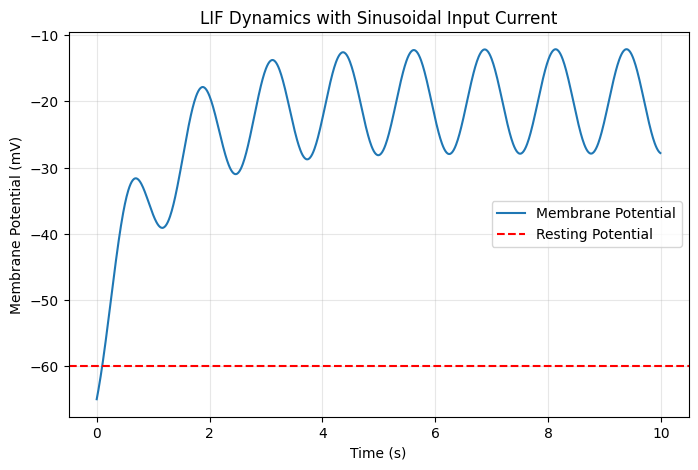

In [8]:
# Input is defined above
# Store membrane potential
mu = np.zeros(step_end)
mu[0] = -65 # 65 mV initial potential

# Simulate dynamics
for i in range (1, step_end):
    mu[i] = mu[i-1] + (mu_0 - mu[i-1] + I[i-1]) * dt
# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, t_max, dt), mu, label="Membrane Potential")
ax.axhline(y=mu_0, color="r", linestyle="--", label="Resting Potential")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Membrane Potential (mV)")
ax.set_title("LIF Dynamics with Sinusoidal Input Current")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

The membrane potential mirrors the input function; we can see that the cyclical shape of the input manifests in the membrane potential, and since the input is positive, the membrane potential is non-decreasing.

However, by $t \approx 6$, the membrane potential levels off (except for the sinusoidal fluctuations). This is because there is a balance between the charge leaking out of the membrane and the input coming into the membrane.

Now, let's add a much larger input, to see how high the membrane potential can get. We'll use the shape of the first input demonstration, but with a value of 100 instead of 4.

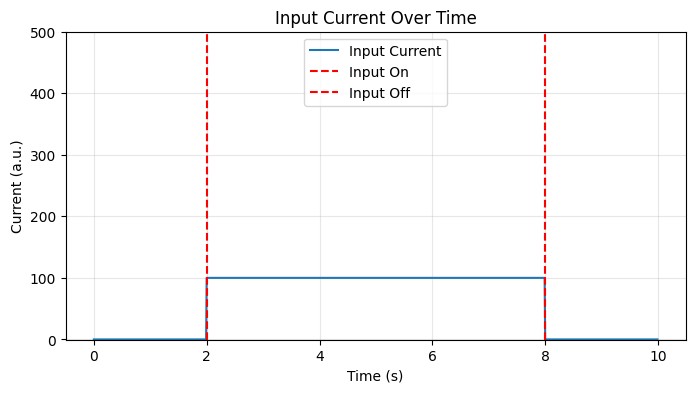

In [9]:
# Define Input Current

I = np.zeros(step_end)
I[200:800] = 100 # input = 100 from 2 s to 8 s

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(0, t_max, dt), I, label="Input Current")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Current (a.u.)")
ax.set_title("Input Current Over Time")
ax.axvline(x=2, color="r", ls="--", label="Input On")
ax.axvline(x=8, color="r", ls="--", label="Input Off")
ax.set_ylim(-0.5,500); ax.legend(); ax.grid(alpha=0.3)
plt.show()

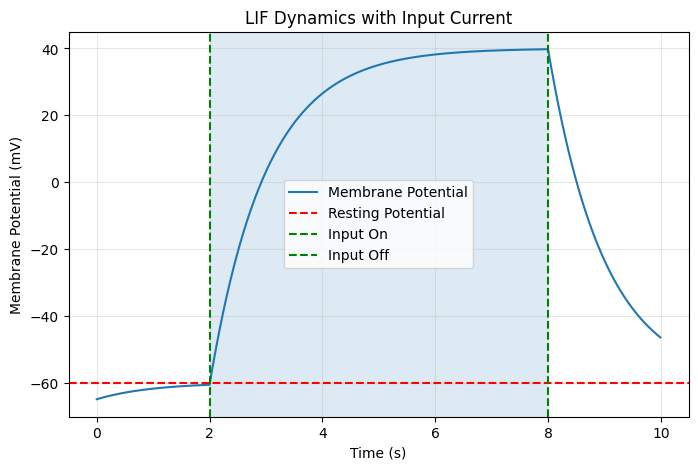

In [10]:
# Same input as above

# Store membrane potential
mu = np.zeros(step_end)
mu[0] = -65 # 65 mV initial potential

# Simulate dynamics
for i in range (1, step_end):
    mu[i] = mu[i-1] + (mu_0 - mu[i-1] + I[i-1]) * dt

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, t_max, dt), mu, label="Membrane Potential")
ax.axhline(y=mu_0, color="r", linestyle="--", label="Resting Potential")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Membrane Potential (mV)")
ax.set_title("LIF Dynamics with Input Current")

# Show input current
ax.axvline(x=2, color="g", ls="--", label="Input On")
ax.axvline(x=8, color="g", ls="--", label="Input Off")
ax.axvspan(2, 8, alpha=0.15)

ax.legend(); ax.grid(alpha=0.3)

plt.show()

With this massive current injection, our LIF neuron is reaching membrane potentials of 40+ mV. This is biologically implausible, as when real neurons depolarize enough, the emit a **spike**. So the next thing we do with our model is to introduce a spike mechanism.

## Spiking

The simplest way to introduce a spiking mechanism for the LIF neuron is to add a conditional statement:
$$
\text{If my membrane voltage reaches $\theta$, then I emit a spike.}
$$
After spiking, the membrane potential *resets* to some value $\mu^{reset}$.

Let's see what the previous example looks like, but with the spiking mechanism added. Let spike threshold $\theta = -50$, and reset value $\mu^{reset} = -80$.

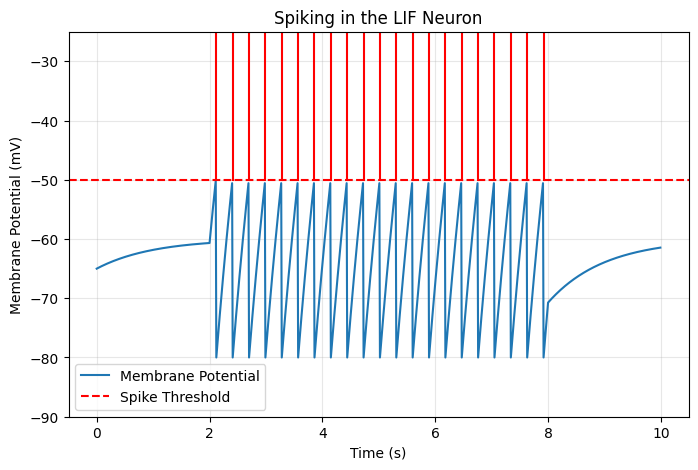

In [11]:
# Input is defined above
# Store membrane potential
mu = np.zeros(step_end)
mu[0] = -65 # 65 mV initial potential

# Spike threshold
theta = -50
mu_reset = -80

# Spike times
spike_times = []

# Simulate dynamics
for i in range (1, step_end):
    mu[i] = mu[i-1] + (mu_0 - mu[i-1] + I[i-1]) * dt
    if mu[i] >= theta:
        mu[i] = mu_reset
        spike_times.append(i * dt)
# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, t_max, dt), mu, label="Membrane Potential")
ax.axhline(y=theta, color="r", linestyle="--", label="Spike Threshold")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Membrane Potential (mV)")
ax.set_title("Spiking in the LIF Neuron")
ax.set_ylim(-90, -25)
# Add spikes
for spike in spike_times:
    ax.plot([spike, spike], [theta, ax.get_ylim()[1]], color='r')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

Now we have spikes! The input current induces relatively constant spiking over the interval that it is turned on.

Now let's bring back the sinusoidal input and see what happens.

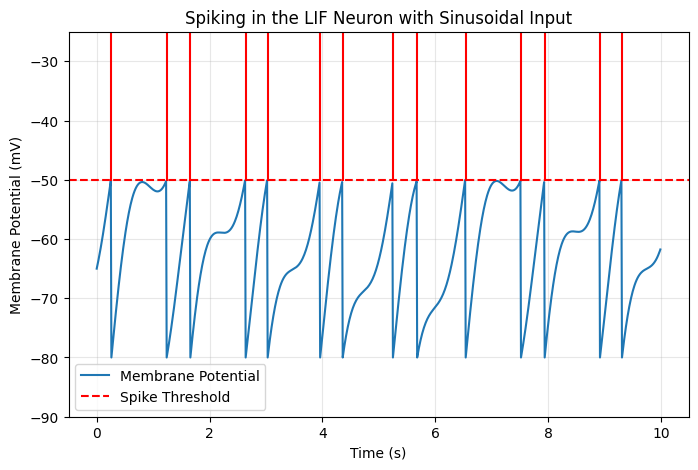

In [12]:
# Sinusoidal input
I = np.zeros(step_end)
for i in range(step_end):
    I[i] = 40 * (1 + np.sin(i / 20))

# Store membrane potential
mu = np.zeros(step_end)
mu[0] = -65 # 65 mV initial potential

# Spike threshold
theta = -50
mu_reset = -80

# Spike times
spike_times = []

# Simulate dynamics
for i in range (1, step_end):
    mu[i] = mu[i-1] + (mu_0 - mu[i-1] + I[i-1]) * dt
    if mu[i] >= theta:
        mu[i] = mu_reset
        spike_times.append(i * dt)
# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(0, t_max, dt), mu, label="Membrane Potential")
ax.axhline(y=theta, color="r", linestyle="--", label="Spike Threshold")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Membrane Potential (mV)")
ax.set_title("Spiking in the LIF Neuron with Sinusoidal Input")
ax.set_ylim(-90, -25)
# Add spikes
for spike in spike_times:
    ax.plot([spike, spike], [theta, ax.get_ylim()[1]], color='r')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

The sinusoidal input brings out a different spiking pattern than the constant input! In reality, the input current that a neuron receives is complicated and depends highly on the neurons that are connected to it. It's the complexity of inputs that feed into neurons that give rise to the vast arrays of spiking activity that neurons exhibit.

## Capacitance and Resistance

We now have a spiking neuron model that mimics biological neurons. But we can make it more powerful...

what if we want neurons to be very sensitive to input! (coincidence detectors)

what if we want neurons to need a LOT of input over more time?